In [3]:
import pandas as pd      # used for data handling (tables, CSV files)
import numpy as np       # used for numerical operations
import matplotlib.pyplot as plt   # used for plotting graphs
import seaborn as sns    # advanced visualization library

In [4]:
train_df = pd.read_csv("train.csv")   # load training dataset
test_df = pd.read_csv("test.csv")     # load testing dataset

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
df = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)

In [ ]:
df.shape          # returns (rows, columns)
df.info()         # data types and null values
df.describe()     # statistical summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id          1000000 non-null  int64  
 1   Sex         1000000 non-null  object 
 2   Age         1000000 non-null  int64  
 3   Height      1000000 non-null  float64
 4   Weight      1000000 non-null  float64
 5   Duration    1000000 non-null  float64
 6   Heart_Rate  1000000 non-null  float64
 7   Body_Temp   1000000 non-null  float64
 8   Calories    750000 non-null   float64
dtypes: float64(6), int64(2), object(1)
memory usage: 68.7+ MB


,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,750000.000000
mean,499999.500000,41.428419,174.704670,75.146179,15.419618,95.482767,40.036213,88.282781
std,288675.278932,15.175728,12.823881,13.981899,8.352851,9.449920,0.779518,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,249999.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,499999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,749999.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,999999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


In [ ]:
df.isnull().sum()

id                 0
Sex                0
Age                0
Height             0
Weight             0
Duration           0
Heart_Rate         0
Body_Temp          0
Calories      250000
dtype: int64

In [ ]:
# Fill missing Calories with the median Calories of people who exercised for the exact same Duration
df["Calories"] = df["Calories"].fillna(df.groupby("Duration")["Calories"].transform("median"))

# Verify that the NaN values are gone (should output 0 for Calories)
df.isnull().sum()

id            0
Sex           0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 57.2+ MB


In [ ]:
df.drop("id", axis=1, inplace=True)

In [ ]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})

In [ ]:
df.head()

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,64,163.0,60.0,8.0,85.0,39.7,34.0
2,1,51,161.0,64.0,7.0,84.0,39.8,29.0
3,0,20,192.0,90.0,25.0,105.0,40.7,140.0
4,1,38,166.0,61.0,25.0,102.0,40.6,146.0


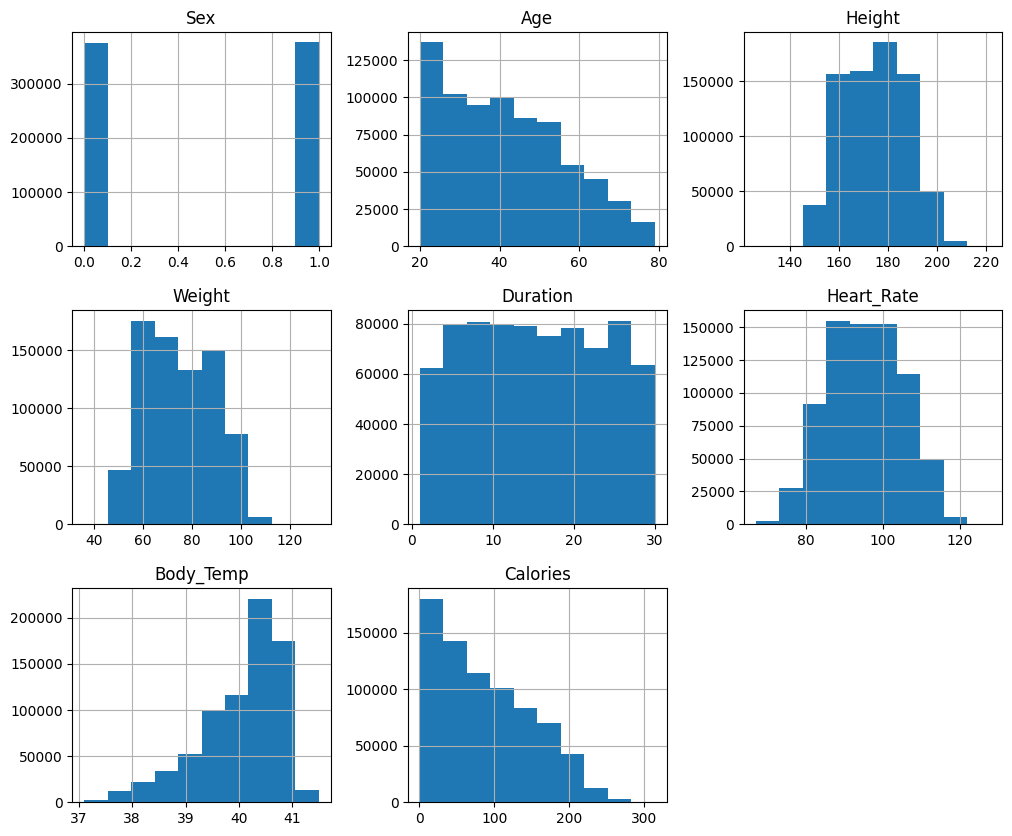

In [ ]:
df.hist(figsize=(12,10))
plt.show()

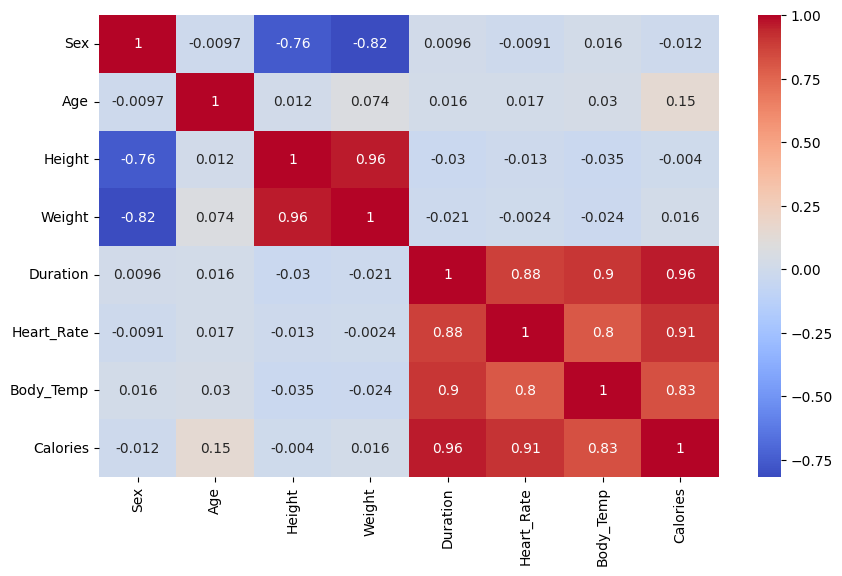

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

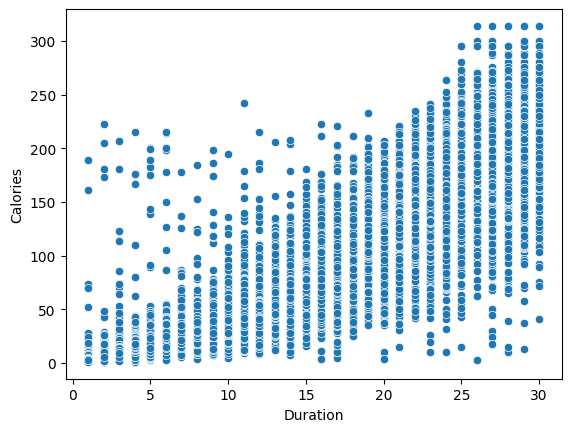

In [ ]:
sns.scatterplot(x="Duration", y="Calories", data=df)
plt.show()

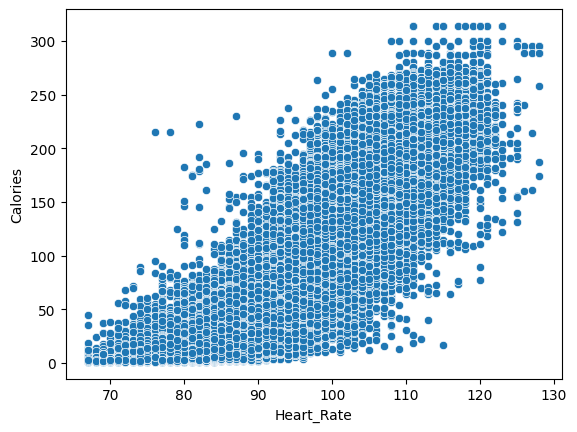

In [ ]:
sns.scatterplot(x="Heart_Rate", y="Calories", data=df)
plt.show()

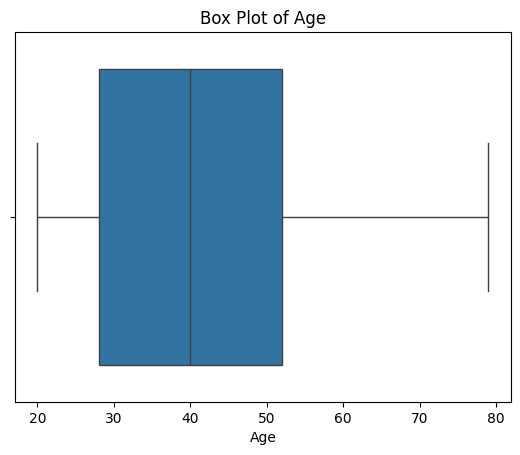

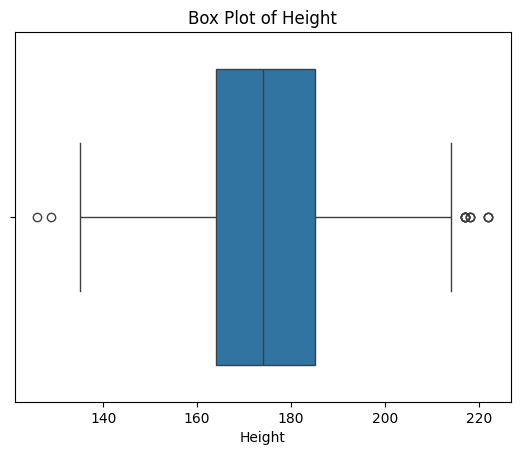

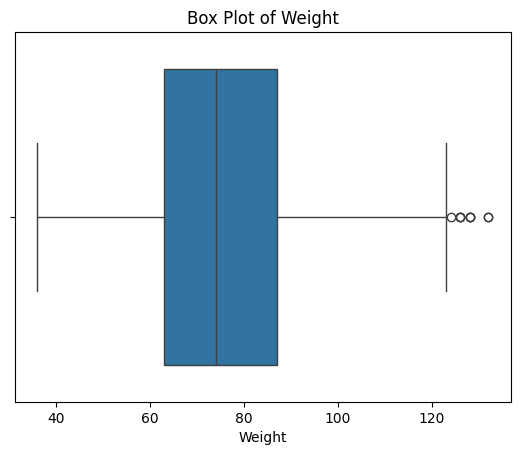

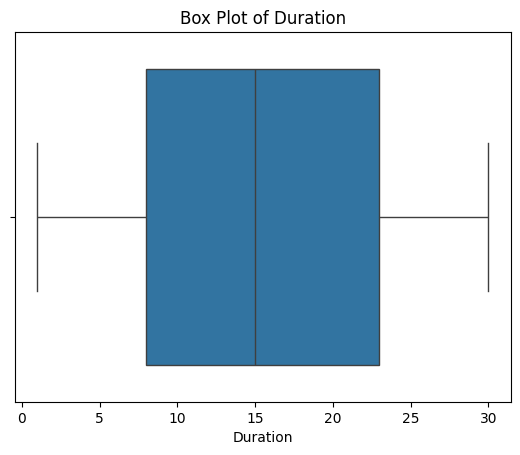

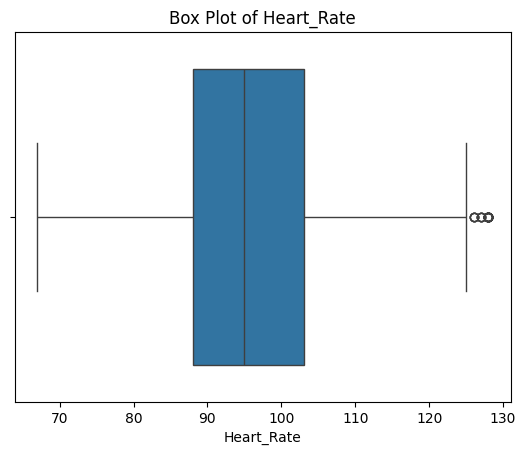

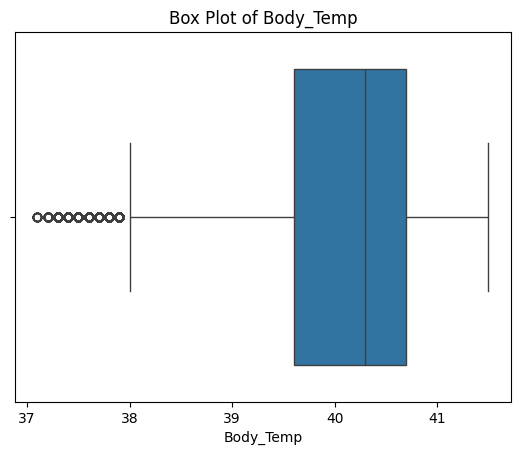

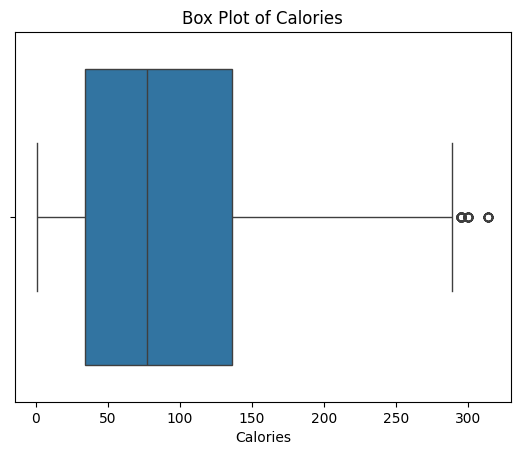

In [ ]:
num_cols = ["Age", "Height", "Weight", "Duration", "Heart_Rate", "Body_Temp", "Calories"]

for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

In [ ]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].apply(lambda x: lower if x < lower else x)
    df[col] = df[col].apply(lambda x: upper if x > upper else x)

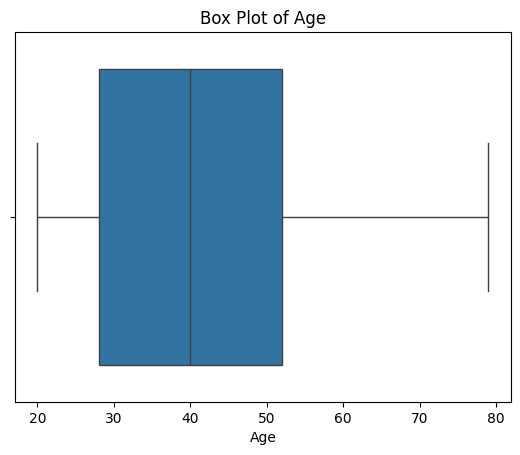

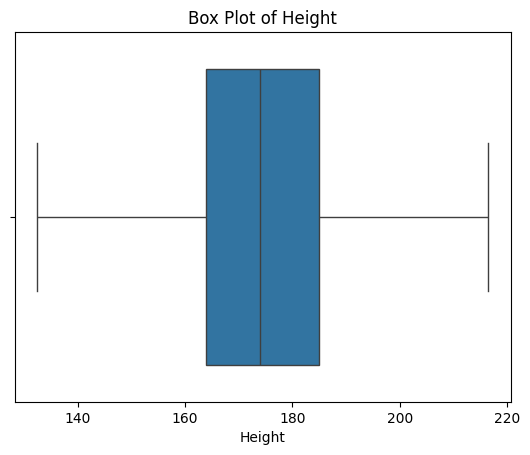

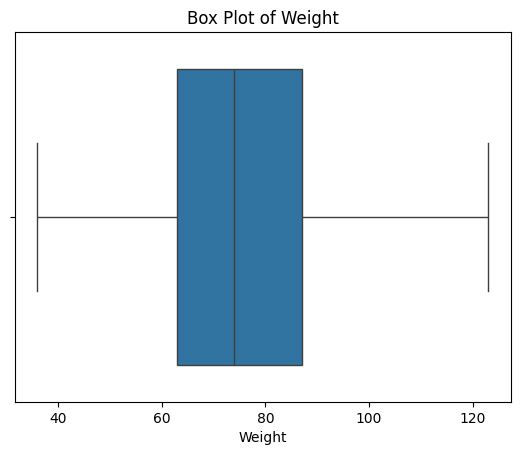

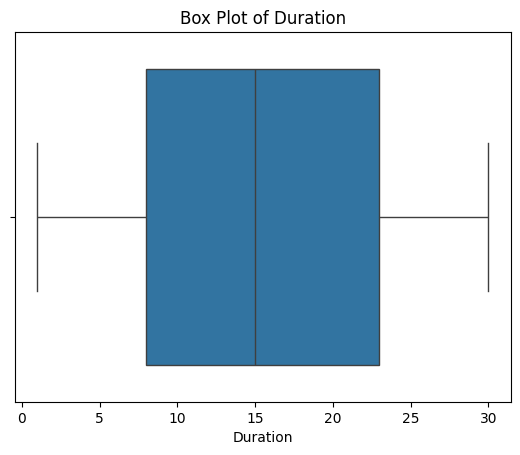

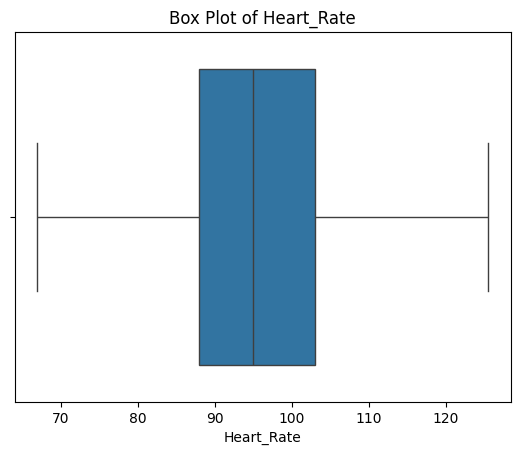

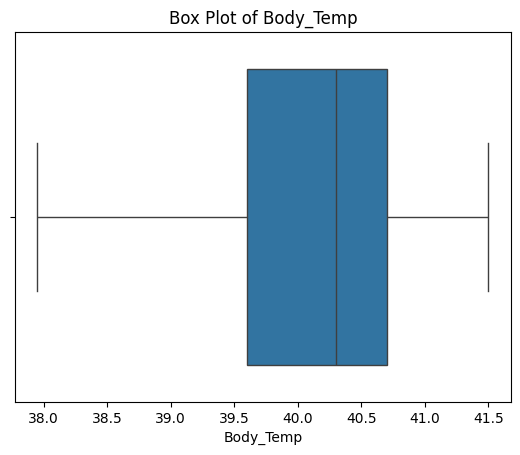

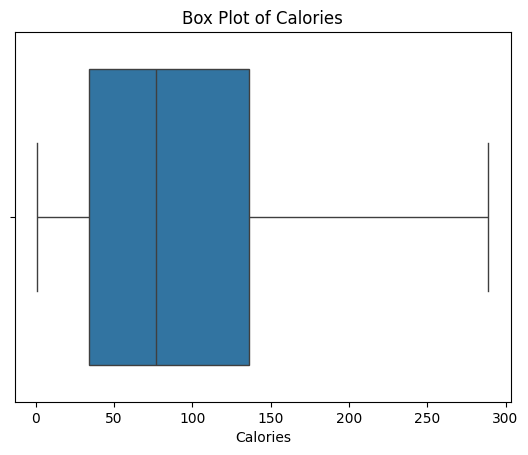

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()